In [1]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

e:\Anaconda\envs\bio\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\Anaconda\envs\bio\Lib\site-packages\muon\_core\preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

In [4]:
%%capture
path_count = '/ix1/ylee/Yifan_Zhang/CellRanger_tests/E11S/outs/'
path = path_count


In [5]:
mdata = mu.read_10x_h5(
    'filtered_feature_bc_matrix.h5', 
)


In [6]:
path_multi = '/ix1/ylee/Yifan_Zhang/CellRanger_tests/E4S_multi/outs/per_sample_outs/E4S_multi/count/sample_'
# for cellranger multi outputs 
# mdata_raw = mu.read_10x_h5(
#     '/ix1/ylee/Yifan_Zhang/CellRanger_tests/E4S_multi/outs/multi/count/'+'raw_feature_bc_matrix.h5', 
# )


In [7]:
mdata.var_names_make_unique()
mdata

MuData object with n_obs × n_vars = 8669 × 33888
  var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
  2 modalities
    rna:	8669 x 33696
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    prot:	8669 x 192
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [8]:
# filtered_prot = mdata_raw['prot'][:, mdata_raw['prot'].var_names.str.startswith('sbc')]
# mdata_raw.mod['prot'] = filtered_prot
# filtered_prot = mdata['prot'][:, mdata['prot'].var_names.str.startswith('sbc')]
# mdata.mod['prot'] = filtered_prot

In [9]:
sbc_rna = mdata['rna'][:, mdata['rna'].var_names.str.startswith('Sgbc')]
sbc_rna.var_names

Index([], dtype='object')

In [10]:
mdata['rna'].var_names

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'A930006A01Rik',
       ...
       'Gm16367', 'ENSMUSG00000094172', 'ENSMUSG00000094887',
       'ENSMUSG00000091585', 'ENSMUSG00000095763', 'ENSMUSG00000095523',
       'ENSMUSG00000095475', 'ENSMUSG00000094855', 'ENSMUSG00000095019',
       'ENSMUSG00000095041'],
      dtype='object', length=33696)

In [11]:
from muon import prot as pt

In [12]:
prot_DF = mdata['prot'].to_df()
isV12 = True
isFirstHalf = True

# V12 first Half    
# rows = [f'sbc{i}' for i in range(1,49)]
# cols = [f'sbc{i}' for i in range(96,144)]

# V12 Second Half
# rows = [f'sbc{i}' for i in range(48, 96)]
# cols = [f'sbc{i}' for i in range(144, 192)]

# All 
# rows = [f'sbc{i}' for i in range(1, 97)]
# cols = [f'sbc{i}' for i in range(97,192)]  

# V11 First 42
# rows = [f'sbc{i}' for i in range(1,41)]
# cols = [f'sbc{i}' for i in range(96,136)]

# V11 second 42
# rows = [f'sbc{i}' for i in range(56, 96)]
# cols = [f'sbc{i}' for i in range(152 ,192)]

rows = [f'sbc{i}' for i in range(1,43)]
cols = [f'sbc{i}' for i in range(97,139)]
ascend = True  # False: interleave from the end of rows and cols

cols_to_keep = [c for c in prot_DF.columns if c in rows or c in cols]
prot_DF_filtered = prot_DF[cols_to_keep]
prot_DF_filtered.head()



,sbc1,sbc2,sbc3,sbc4,sbc5,sbc6,sbc7,sbc8,sbc9,sbc10,...,sbc129,sbc130,sbc131,sbc132,sbc133,sbc134,sbc135,sbc136,sbc137,sbc138
AAACCAAAGCTAGCCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCAAAGGAGGCTA-1,0.0,0.0,0.0,2.0,1.0,2.0,3.0,1.0,0.0,0.0,...,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCATTCCATAGTG-1,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,1.0,...,1.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
AAACCATTCGAACGCT-1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCATTCGTTAGGC-1,0.0,0.0,0.0,0.0,1.0,0.0,10.0,0.0,0.0,2.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [13]:
len(cols)

42

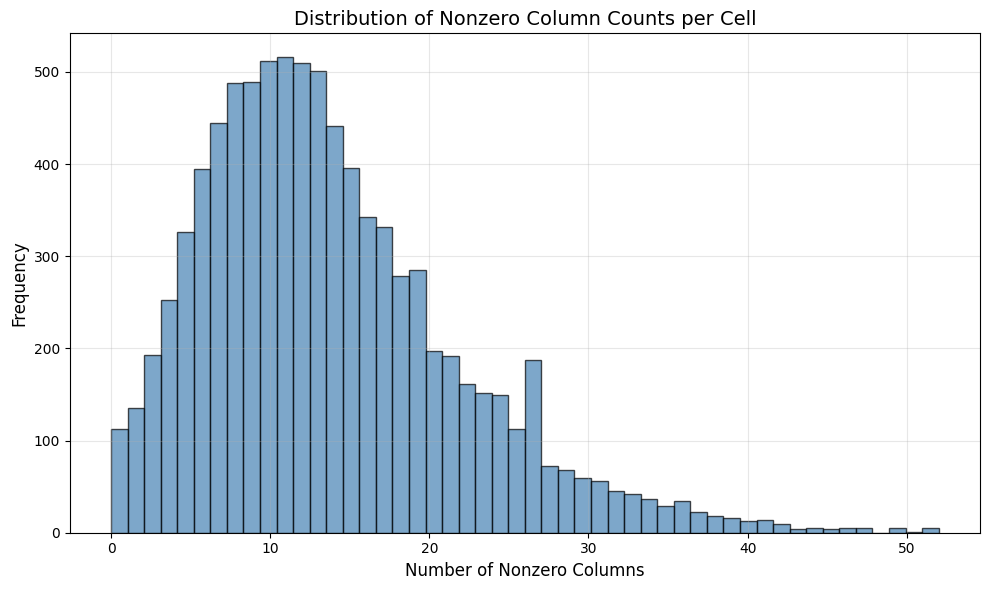

Summary Statistics for Nonzero Column Counts:
Mean: 13.82
Median: 12.00
Std Dev: 7.97
Min: 0
Max: 52


In [14]:
# Count nonzero columns per row
nonzero_col_counts = (prot_DF_filtered != 0).sum(axis=1)

# Plot distribution
plt.figure(figsize=(10, 6), dpi=100)
plt.hist(nonzero_col_counts, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Number of Nonzero Columns', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Nonzero Column Counts per Cell', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Summary Statistics for Nonzero Column Counts:")
print(f"Mean: {nonzero_col_counts.mean():.2f}")
print(f"Median: {nonzero_col_counts.median():.2f}")
print(f"Std Dev: {nonzero_col_counts.std():.2f}")
print(f"Min: {nonzero_col_counts.min()}")
print(f"Max: {nonzero_col_counts.max()}")

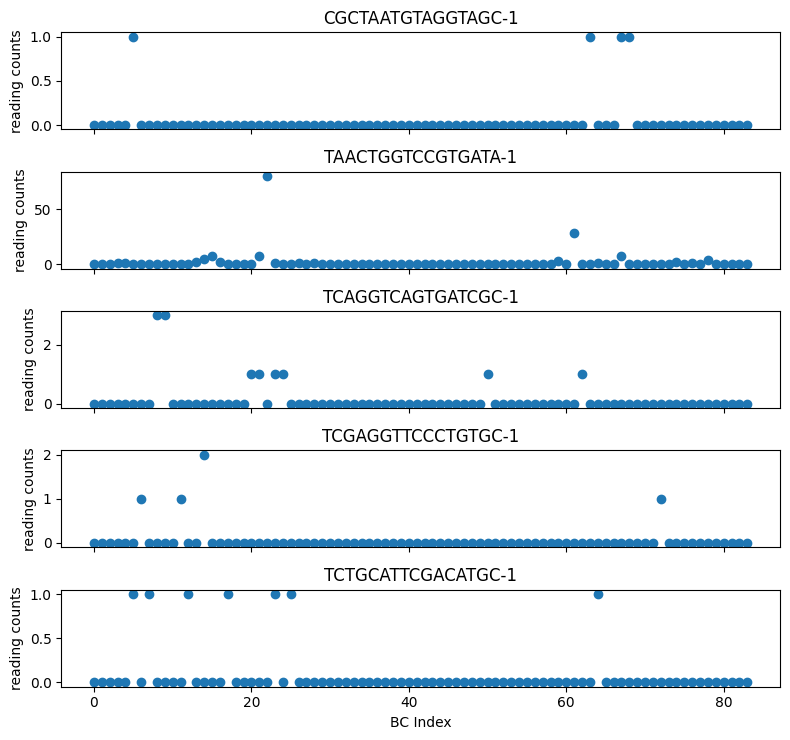

In [15]:
import matplotlib.pyplot as plt

k = 5 # number of rows to sample
sampled = prot_DF_filtered.sample(n=k, replace=False)

fig, axes = plt.subplots(
    nrows=k,
    ncols=1,
    figsize=(8, 1.5 * k),  # reduced height per subplot
    sharex=True
)

# If k == 1, axes is not a list
if k == 1:
    axes = [axes]

for ax, (idx, row) in zip(axes, sampled.iterrows()):
    ax.scatter(np.arange(len(row)), row.values)
    # ax.set_ylabel(str(idx), rotation=45, labelpad=30, va="center")
    ax.set_ylabel("reading counts")
    ax.set_title(str(idx))

axes[-1].set_xlabel("BC Index")
axes[-1].set_xlabel("BC Index")
plt.tight_layout()
plt.savefig('BC.png')
plt.show()


In [16]:
BC_by_cell = prot_DF_filtered.where(prot_DF_filtered <= 1, 1)
BC_total = BC_by_cell.sum(axis = 0)

In [51]:
BC_by_cell

,sbc1,sbc2,sbc3,sbc4,sbc5,sbc6,sbc7,sbc8,sbc9,sbc10,...,sbc129,sbc130,sbc131,sbc132,sbc133,sbc134,sbc135,sbc136,sbc137,sbc138
AAACCAAAGCTAGCCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCAAAGGAGGCTA-1,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCATTCCATAGTG-1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
AAACCATTCGAACGCT-1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCATTCGTTAGGC-1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTACGTGCAGCCT-1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
TGTGTTAGTGATGAAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TGTGTTAGTTAGCCCA-1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
TGTGTTAGTTATGCGT-1,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [18]:
chunk = 12

r = list(rows)
c = list(cols)
if not ascend:
    r = r[::-1]
    c = c[::-1]

new_order = []
i = 0
while True:
    r_chunk = r[i * chunk : (i + 1) * chunk]
    c_chunk = c[i * chunk : (i + 1) * chunk]
    if not r_chunk and not c_chunk:
        break
    new_order.extend(r_chunk)
    new_order.extend(c_chunk)
    i += 1

BC_total_reordered = BC_total[new_order].to_list()

# X-axis: tick at start and end index of each row/col chunk along new_order
chunk_x_ticks = []
chunk_x_labels = []
pos = 0
i = 0
while True:
    r_chunk = r[i * chunk : (i + 1) * chunk]
    c_chunk = c[i * chunk : (i + 1) * chunk]
    if not r_chunk and not c_chunk:
        break
    if r_chunk:
        chunk_x_ticks.extend([pos, pos + len(r_chunk) - 1])
        chunk_x_labels.extend([str(r_chunk[0]), str(r_chunk[-1])])
        pos += len(r_chunk)
    if c_chunk:
        chunk_x_ticks.extend([pos, pos + len(c_chunk) - 1])
        chunk_x_labels.extend([str(c_chunk[0]), str(c_chunk[-1])])
        pos += len(c_chunk)
    i += 1

# BC_total = BC_total_reoredered

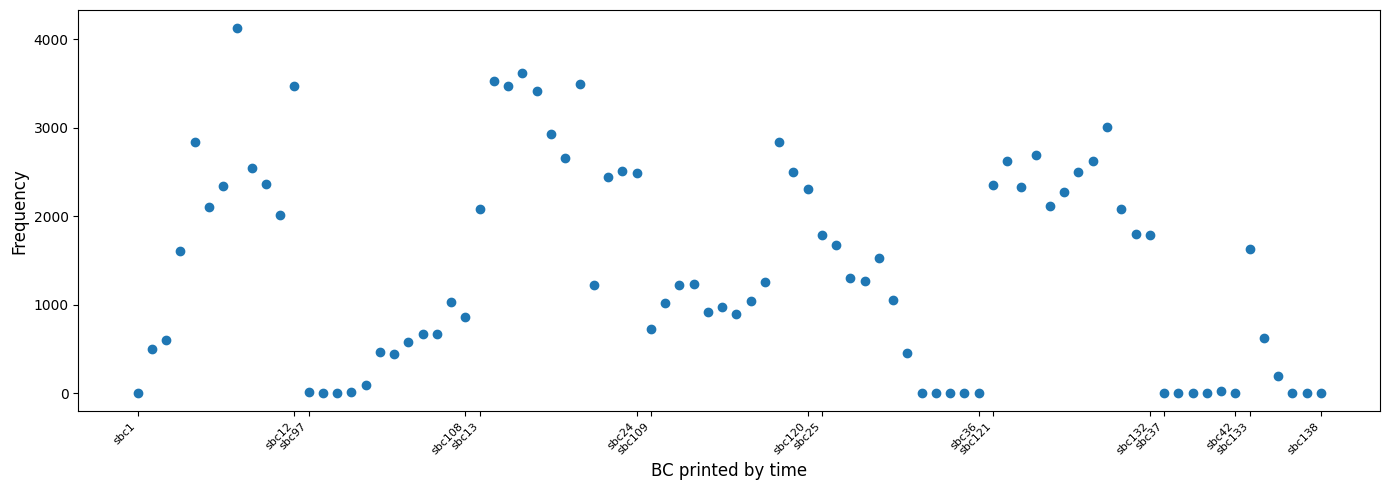

In [19]:
plt.figure(figsize=(14, 5))
plt.scatter(np.arange(len(BC_total_reordered)), np.array(BC_total_reordered))
plt.xticks(chunk_x_ticks, chunk_x_labels, rotation=45, ha="right", fontsize=8)
plt.xlabel("BC printed by time", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()

## load BC from gene

In [20]:
df = pd.DataFrame(index=rows, columns=cols)
for r in rows:
    for c in cols:
        df.loc[r, c] = f'{r}-{c}'

x = []
y = []

### Search with only 2 BCs

## Select top

In [21]:
ratio = 2

def _top_name_and_confident(counts: pd.Series, order: list, fold: float):
    s_full = pd.to_numeric(counts.reindex(order), errors="coerce").replace(0, np.nan)
    s = s_full.dropna()
    if s.empty:
        return None, False, pd.Series(dtype=float), pd.Series(dtype=np.float64)
    tops = s.nlargest(min(2, len(s)))
    top1 = float(tops.iloc[0])
    top2 = float(tops.iloc[1]) if len(tops) > 1 else 0.0
    name = tops.index[0]
    confident = top1 >= fold * top2
    i0 = order.index(name)
    detail = {}
    dist_ratio = {0: 1.0}
    for j, bc in enumerate(order):
        v = s_full.loc[bc]
        if pd.isna(v) or bc == name:
            continue
        detail[(bc, "ratio")] = float(v) / top1
        detail[(bc, "dist")] = j - i0
        dist_ratio[j - i0] = float(v) / top1
    dist_ratio_series = pd.Series(dist_ratio, dtype=np.float64).sort_index()
    return name, confident, pd.Series(detail), dist_ratio_series


df_cells = prot_DF_filtered

x, y, label = [], [], []
ratio_rows = []
row_dr_rows = []
col_dr_rows = []
for bc in df_cells.index:
    name_x, cx, rx, dr_x = _top_name_and_confident(df_cells.loc[bc, rows], rows, ratio)
    name_y, cy, ry, dr_y = _top_name_and_confident(df_cells.loc[bc, cols], cols, ratio)
    x.append(name_x)
    y.append(name_y)
    label.append("confident" if (cx and cy) else "non-confident")
    row_dr_rows.append(dict(dr_x))
    col_dr_rows.append(dict(dr_y))
    
ratio_df = pd.DataFrame(ratio_rows, index=df_cells.index)
row_dist_ratio_df = pd.DataFrame(row_dr_rows, index=df_cells.index)
col_dist_ratio_df = pd.DataFrame(col_dr_rows, index=df_cells.index)
xy_raw = pd.DataFrame({"x": x, "y": y, "label": label}, index=df_cells.index)


In [22]:
row_dist_ratio_df = row_dist_ratio_df[sorted(row_dist_ratio_df.columns)]
row_dist_ratio_df = row_dist_ratio_df.fillna(0)

col_dist_ratio_df = col_dist_ratio_df[sorted(col_dist_ratio_df.columns)]
col_dist_ratio_df = col_dist_ratio_df.fillna(0)

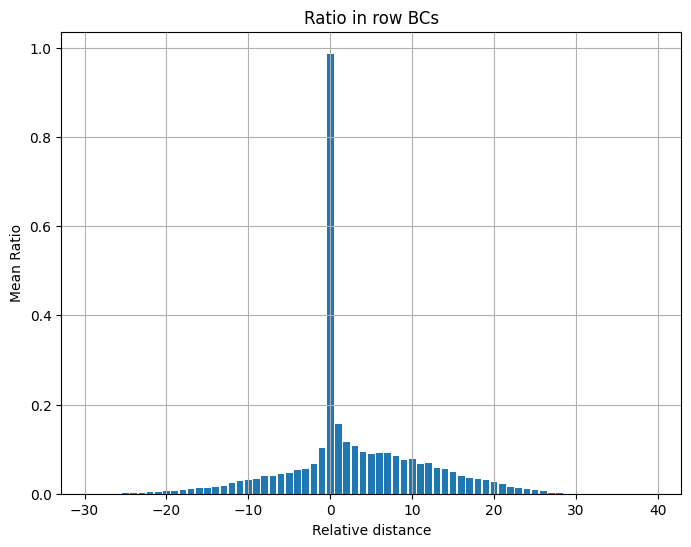

In [23]:
a = row_dist_ratio_df.mean(axis=0)
plt.figure(figsize=(8,6))
plt.bar(a.index, a.values, width=0.8)
plt.xlabel("Relative distance")
plt.ylabel("Mean Ratio")
plt.title("Ratio in row BCs")
plt.grid(True)
plt.show()

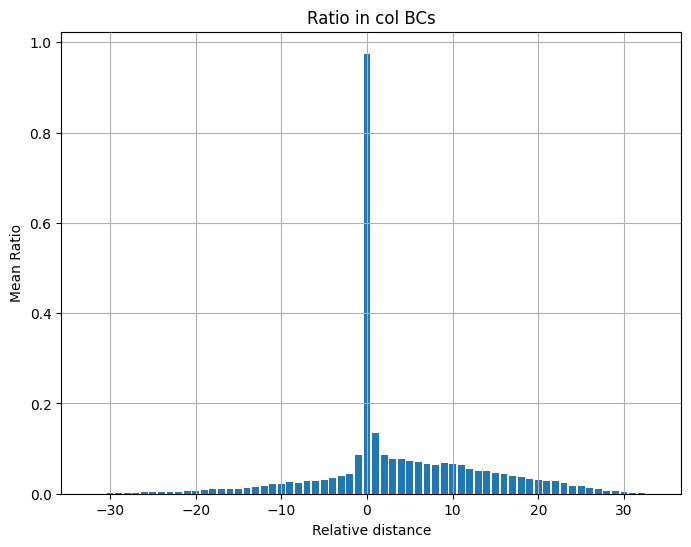

In [24]:
b = col_dist_ratio_df.mean(axis=0)
plt.figure(figsize=(8,6))
plt.bar(b.index, b.values, width=0.8)
plt.xlabel("Relative distance")
plt.ylabel("Mean Ratio")
plt.title("Ratio in col BCs")
plt.grid(True)
plt.show()

In [25]:
xy_raw

,x,y,label
AAACCAAAGCTAGCCG-1,sbc19,sbc107,confident
AAACCAAAGGAGGCTA-1,sbc12,sbc110,confident
AAACCATTCCATAGTG-1,sbc5,sbc130,non-confident
AAACCATTCGAACGCT-1,sbc8,sbc106,non-confident
AAACCATTCGTTAGGC-1,sbc7,sbc114,non-confident
...,...,...,...
TGTGTACGTGCAGCCT-1,sbc25,sbc119,confident
TGTGTTAGTGATGAAT-1,sbc16,sbc124,confident
TGTGTTAGTTAGCCCA-1,sbc14,sbc120,confident
TGTGTTAGTTATGCGT-1,sbc14,sbc129,confident


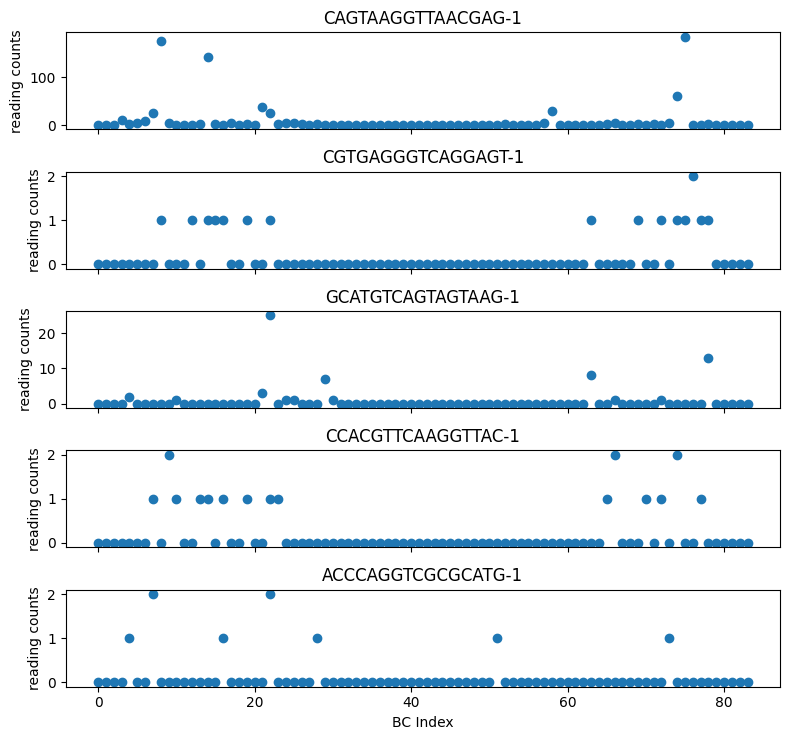

In [26]:
import matplotlib.pyplot as plt
k = 5  # number of rows to sample
confident_rows = xy_raw[xy_raw['label'] == 'non-confident']
sampled = prot_DF_filtered.loc[confident_rows.index].sample(n=k, replace=False)

fig, axes = plt.subplots(
    nrows=k,
    ncols=1,
    figsize=(8, 1.5 * k),  # reduced height per subplot
    sharex=True
)

# If k == 1, axes is not a list
if k == 1:
    axes = [axes]

for ax, (idx, row) in zip(axes, sampled.iterrows()):
    ax.scatter(np.arange(len(row)), row.values)
    # ax.set_ylabel(str(idx), rotation=45, labelpad=30, va="center")
    ax.set_ylabel("reading counts")
    ax.set_title(str(idx))

axes[-1].set_xlabel("BC Index")
axes[-1].set_xlabel("BC Index")
plt.tight_layout()
plt.savefig('BC.png')
plt.show()

# UMI QC

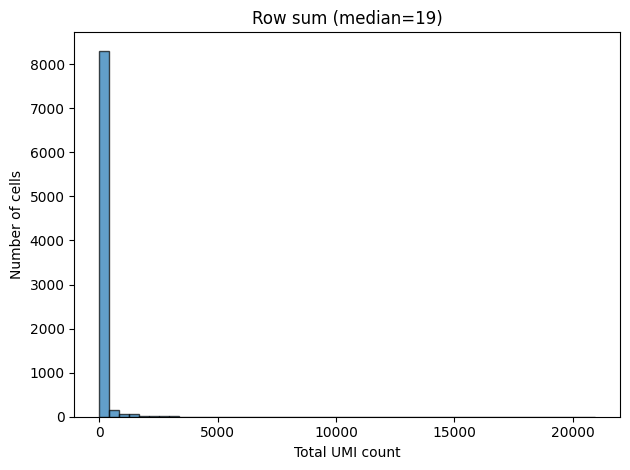

In [27]:
nonzero_per_row = (prot_DF_filtered != 0).sum(axis=1)
sum_per_row = prot_DF_filtered.sum(axis=1)

plt.hist(sum_per_row, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Total UMI count")
plt.ylabel("Number of cells")
plt.title(f"Row sum (median={sum_per_row.median():.0f})")

plt.tight_layout()
plt.show()

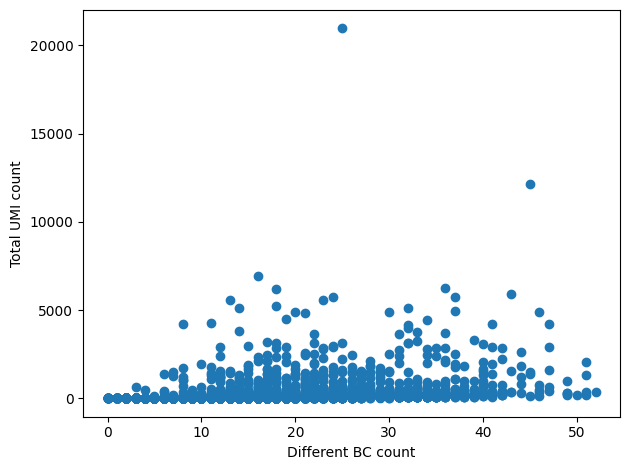

In [28]:
plt.scatter(nonzero_per_row, sum_per_row)
plt.xlabel("Different BC count")
plt.ylabel("Total UMI count")
plt.tight_layout()
plt.show()

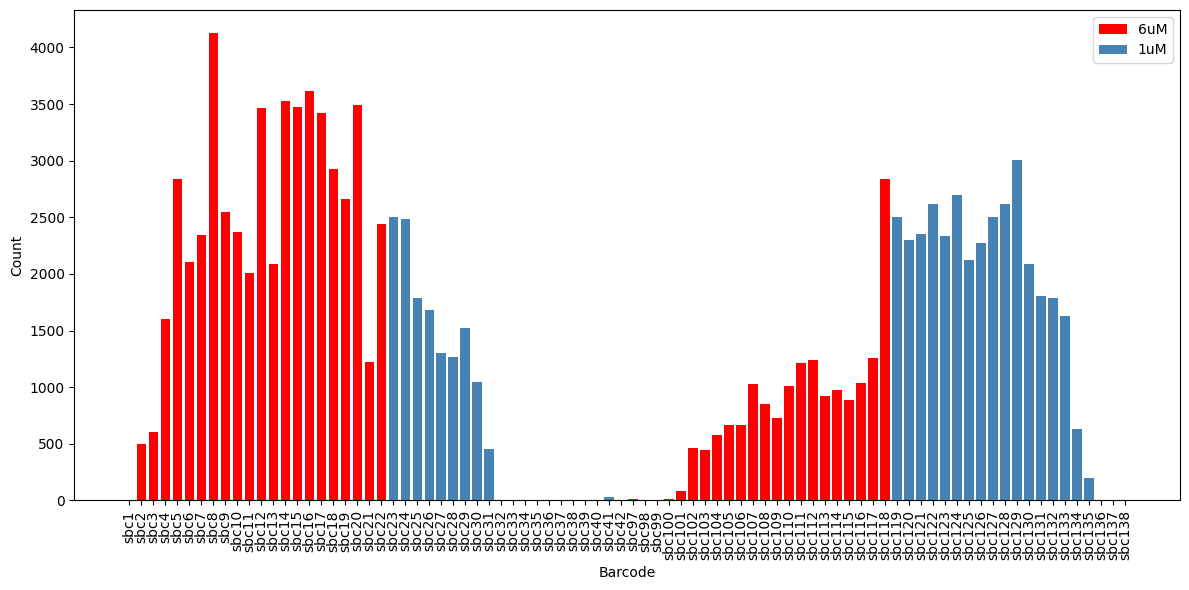

In [56]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Define which indices get red
red_set = set([f'sbc{i}' for i in range(1, 23)] + [f'sbc{i}' for i in range(97, 119)])

colors = ['red' if idx in red_set else 'steelblue' for idx in BC_appearance.index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(BC_appearance.index, BC_appearance.values, color=colors)
ax.set_xlabel('Barcode')
ax.set_ylabel('Count')

legend_elements = [
    Patch(facecolor='red',      label='6uM'),
    Patch(facecolor='steelblue', label='1uM'),
]
ax.legend(handles=legend_elements)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

([<matplotlib.axis.XTick at 0x24f2147cb90>,
 [Text(0, 0, 'sbc1'),
  Text(5, 0, 'sbc6'),
  Text(10, 0, 'sbc11'),
  Text(15, 0, 'sbc16'),
  Text(20, 0, 'sbc21'),
  Text(25, 0, 'sbc26'),
  Text(30, 0, 'sbc31'),
  Text(35, 0, 'sbc36'),
  Text(40, 0, 'sbc41'),
  Text(45, 0, 'sbc100'),
  Text(50, 0, 'sbc105'),
  Text(55, 0, 'sbc110'),
  Text(60, 0, 'sbc115'),
  Text(65, 0, 'sbc120'),
  Text(70, 0, 'sbc125'),
  Text(75, 0, 'sbc130'),
  Text(80, 0, 'sbc135')])

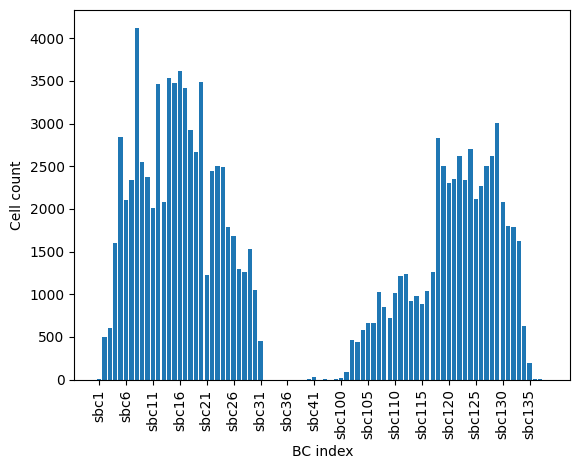

In [29]:
SBC_DF_binary = prot_DF_filtered.applymap(lambda x: 1 if x > 0 else 0)
BC_appearance = SBC_DF_binary.sum(axis=0)
plt.bar(BC_appearance.index, BC_appearance.values)
plt.xlabel("BC index")
plt.ylabel("Cell count")
plt.xticks(ticks=np.arange(0, len(BC_appearance.index), step=5), labels=BC_appearance.index[::5], rotation=90)

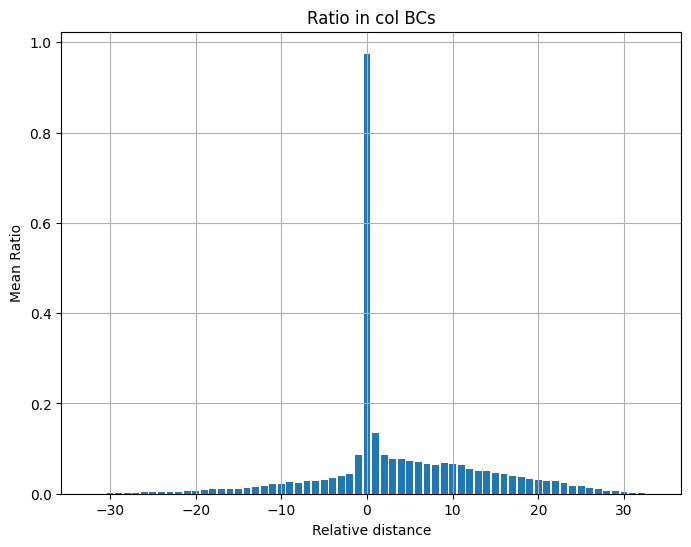

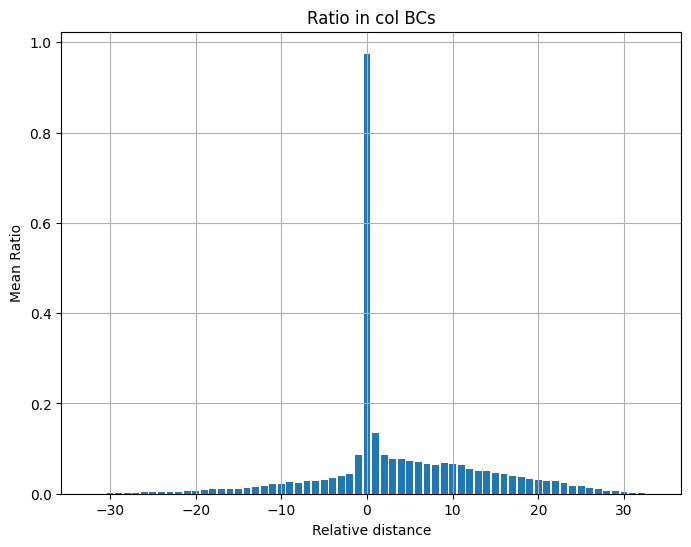

In [30]:
k_top = 10

top_k_bcs = BC_appearance.nlargest(k_top).index
# top_k_bcs = BC_appearance.nsmallest(k_top).index

row_center_series = []
col_center_series = []

for center_bc in top_k_bcs:
    if center_bc in rows:
        order = rows
    elif center_bc in cols:
        order = cols
    else:
        continue
    i0 = order.index(center_bc)
    center_val = float(BC_appearance[center_bc])
    dr = {}
    for j, bc in enumerate(order):
        val = BC_appearance.get(bc, 0)
        if val == 0:
            continue
        dr[j - i0] = float(val) / center_val
    s = pd.Series(dr, dtype=np.float64, name=center_bc)
    if center_bc in rows:
        row_center_series.append(s)
    else:
        col_center_series.append(s)

row_bc_dist_ratio_df = pd.DataFrame(row_center_series)
row_bc_dist_ratio_df = row_bc_dist_ratio_df[sorted(row_bc_dist_ratio_df.columns)].fillna(0)
a = col_dist_ratio_df.mean(axis=0)
plt.figure(figsize=(8,6))
plt.bar(a.index, a.values, width=0.8)
plt.xlabel("Relative distance")
plt.ylabel("Mean Ratio")
plt.title("Ratio in col BCs")
plt.grid(True)
plt.show()

col_bc_dist_ratio_df = pd.DataFrame(col_center_series)
col_bc_dist_ratio_df = col_bc_dist_ratio_df[sorted(col_bc_dist_ratio_df.columns)].fillna(0)
b = col_dist_ratio_df.mean(axis=0)
plt.figure(figsize=(8,6))
plt.bar(b.index, b.values, width=0.8)
plt.xlabel("Relative distance")
plt.ylabel("Mean Ratio")
plt.title("Ratio in col BCs")
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Row sum — top-10 BC cells (n=8295, median=20)')

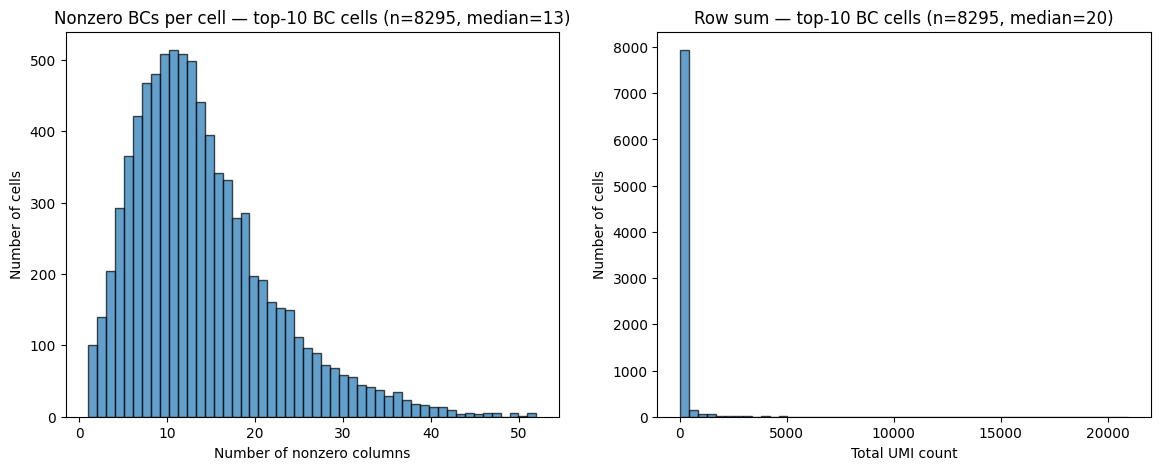

In [31]:
mask = prot_DF_filtered[top_k_bcs].any(axis=1)
nonzero_topk = nonzero_per_row[mask]
sum_topk = sum_per_row[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(nonzero_topk, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Number of nonzero columns")
axes[0].set_ylabel("Number of cells")
axes[0].set_title(f"Nonzero BCs per cell — top-{k_top} BC cells (n={mask.sum()}, median={int(nonzero_topk.median())})")

axes[1].hist(sum_topk, bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Total UMI count")
axes[1].set_ylabel("Number of cells")
axes[1].set_title(f"Row sum — top-{k_top} BC cells (n={mask.sum()}, median={sum_topk.median():.0f})")

Text(0, 0.5, 'Number of cells')

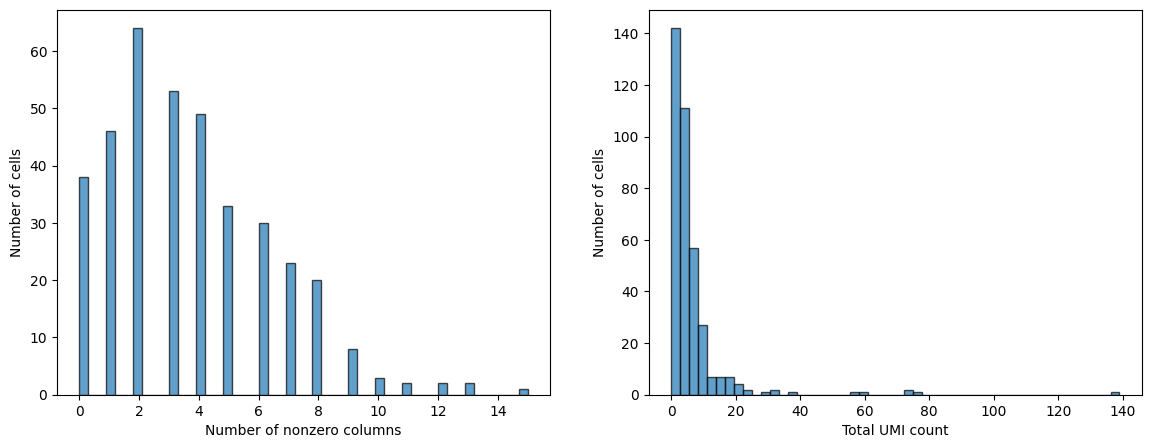

In [32]:
mask = prot_DF_filtered[top_k_bcs].any(axis=1)
nonzero_topk = nonzero_per_row[~mask]
sum_topk = sum_per_row[~mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(nonzero_topk, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Number of nonzero columns")
axes[0].set_ylabel("Number of cells")

axes[1].hist(sum_topk, bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Total UMI count")
axes[1].set_ylabel("Number of cells")


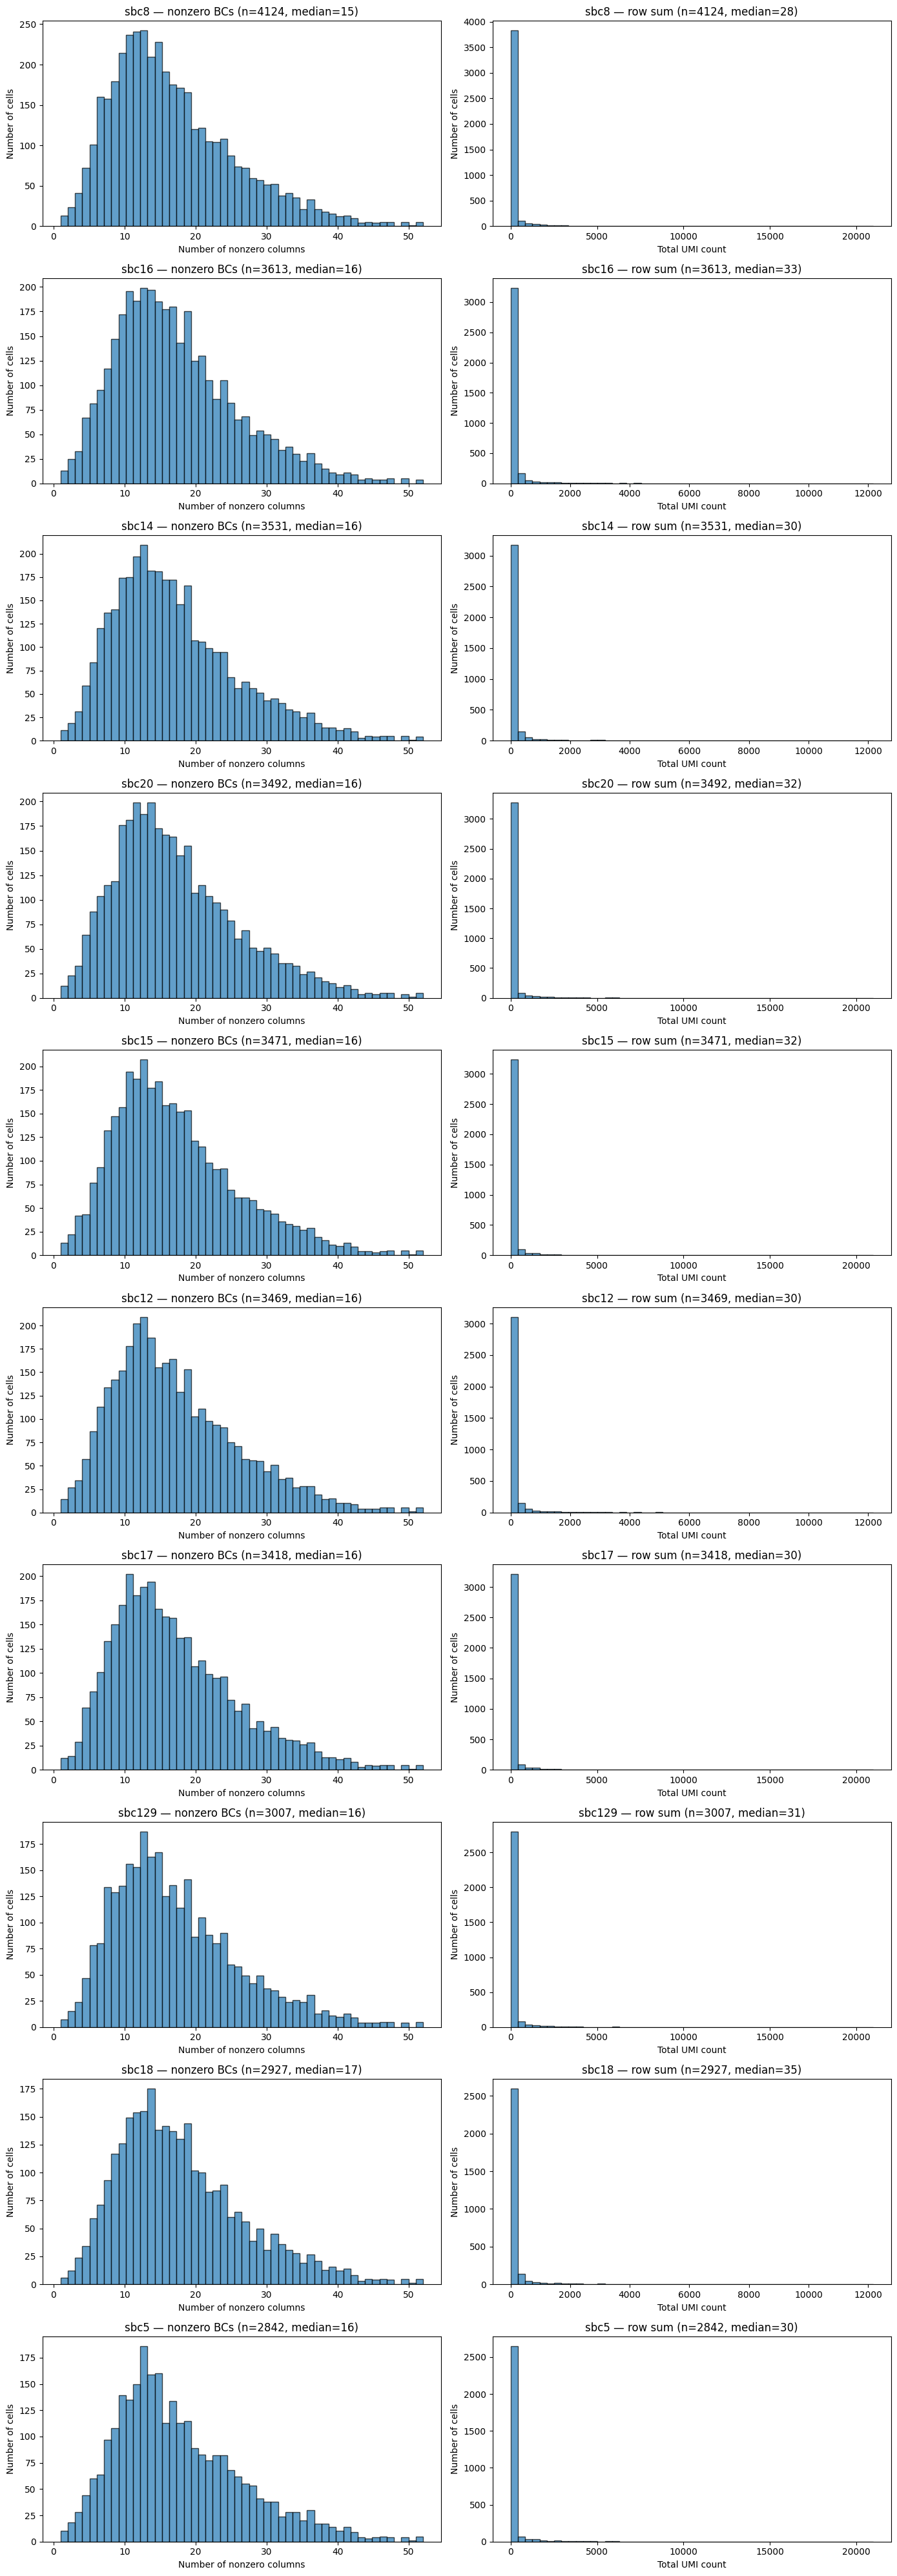

In [33]:
# Loop through all BCs
fig, axes = plt.subplots(k_top, 2, figsize=(14, 4 * k_top))

for row_idx, bc in enumerate(top_k_bcs):
    mask = prot_DF_filtered[bc] > 0
    nonzero_topk = nonzero_per_row[mask]
    sum_topk = sum_per_row[mask]

    axes[row_idx, 0].hist(nonzero_topk, bins=50, edgecolor="black", alpha=0.7)
    axes[row_idx, 0].set_xlabel("Number of nonzero columns")
    axes[row_idx, 0].set_ylabel("Number of cells")
    axes[row_idx, 0].set_title(f"{bc} — nonzero BCs (n={mask.sum()}, median={int(nonzero_topk.median())})")

    axes[row_idx, 1].hist(sum_topk, bins=50, edgecolor="black", alpha=0.7)
    axes[row_idx, 1].set_xlabel("Total UMI count")
    axes[row_idx, 1].set_ylabel("Number of cells")
    axes[row_idx, 1].set_title(f"{bc} — row sum (n={mask.sum()}, median={sum_topk.median():.0f})")

plt.tight_layout()
plt.show()

# Demux alg

In [34]:
from spatial_barcode_demux import demux_all_cells, plot_cell

In [44]:
non_conf_mask = xy_raw["label"] == "non-confident"
non_conf_idx = xy_raw.index[non_conf_mask]
conf_idx = xy_raw.index[~non_conf_mask]
print(f"Confident: {len(conf_idx)}, Non-confident: {len(non_conf_idx)}")

demux_df = demux_all_cells(prot_DF_filtered.loc[non_conf_idx], threshold_k=1.50)
demux_xy = demux_df[["cell", "x", "y"]].copy()
demux_xy["label"] = "non-confident"
demux_xy = demux_xy.set_index("cell")

xy_raw = pd.concat([xy_raw.loc[conf_idx], demux_xy])

adata = mdata['rna'].copy()
adata.obs["spatial_x"] = xy_raw.reindex(adata.obs_names)["x"]
adata.obs["spatial_y"] = xy_raw.reindex(adata.obs_names)["y"]
adata.obs["spatial_label"] = xy_raw.reindex(adata.obs_names)["label"]
print(adata.obs[["spatial_x", "spatial_y", "spatial_label"]].head())
xy_raw

Confident: 2572, Non-confident: 6097
Half 1: 42 barcodes (sbc1 -> sbc42)
Half 2: 42 barcodes (sbc97 -> sbc138)
Total cells: 6097
Threshold multiplier: 1.5
Running demux...

Done! Results summary:
  Low confidence (<10%) -- half1: 1468, half2: 1950
  Fallback (no peaks) -- half1: 1077, half2: 1866
                   spatial_x spatial_y  spatial_label
AAACCAAAGCTAGCCG-1     sbc19    sbc107      confident
AAACCAAAGGAGGCTA-1     sbc12    sbc110      confident
AAACCATTCCATAGTG-1     sbc10    sbc128  non-confident
AAACCATTCGAACGCT-1     sbc12    sbc106  non-confident
AAACCATTCGTTAGGC-1     sbc11    sbc126  non-confident


,x,y,label
AAACCAAAGCTAGCCG-1,sbc19,sbc107,confident
AAACCAAAGGAGGCTA-1,sbc12,sbc110,confident
AAACGAATCCATCCTG-1,sbc24,sbc123,confident
AAACGACAGGCGTCCA-1,sbc18,sbc130,confident
AAACGATGTTATGGTC-1,sbc14,sbc116,confident
...,...,...,...
TGTGGTCAGTCATTGG-1,sbc4,sbc121,non-confident
TGTGGTTGTAACCCAT-1,sbc15,sbc108,non-confident
TGTGGTTGTCTAACTA-1,sbc14,sbc121,non-confident
TGTGGTTGTGAGCAGT-1,sbc13,sbc121,non-confident


In [45]:
from collections import Counter

# Count the occurrences of (x, y) pairs in xy_raw
pair_counts = xy_raw[["x", "y"]].value_counts().reset_index()
pair_counts.columns = ["x", "y", "count"]

# Sort by count descending for clarity
pair_counts = pair_counts.sort_values(by="count", ascending=False)

# Optionally display the top few
print(pair_counts.head())

       x       y  count
0  sbc14  sbc122     56
1  sbc15  sbc122     52
2  sbc16  sbc128     51
3   sbc8  sbc118     48
4  sbc12  sbc118     48


In [46]:
adata.obs['BC_counts'] = nonzero_per_row 
adata.obs['UMI_total'] = sum_per_row
adata

AnnData object with n_obs × n_vars = 8669 × 33696
    obs: 'spatial_x', 'spatial_y', 'spatial_label', 'BC_counts', 'UMI_total'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

# PLot

In [47]:
def pivot_xy_counts(xy_df):
    if xy_df.empty:
        return pd.DataFrame(0.0, index=list(df.index), columns=list(df.columns))
    heatmap_data = xy_df[["x", "y"]].value_counts().reset_index(
        name="count").pivot(index="x", columns="y", values="count").fillna(0)
    heatmap_data = heatmap_data.reindex(df.index).T.reindex(df.columns).T.fillna(0).T
    return heatmap_data

xy_nn = xy_raw.dropna(subset=["x", "y"])



In [48]:
print(len(xy_nn[xy_nn["label"] == "confident"]))
print(len(xy_nn[xy_nn["label"] == "non-confident"]))

2572
6097


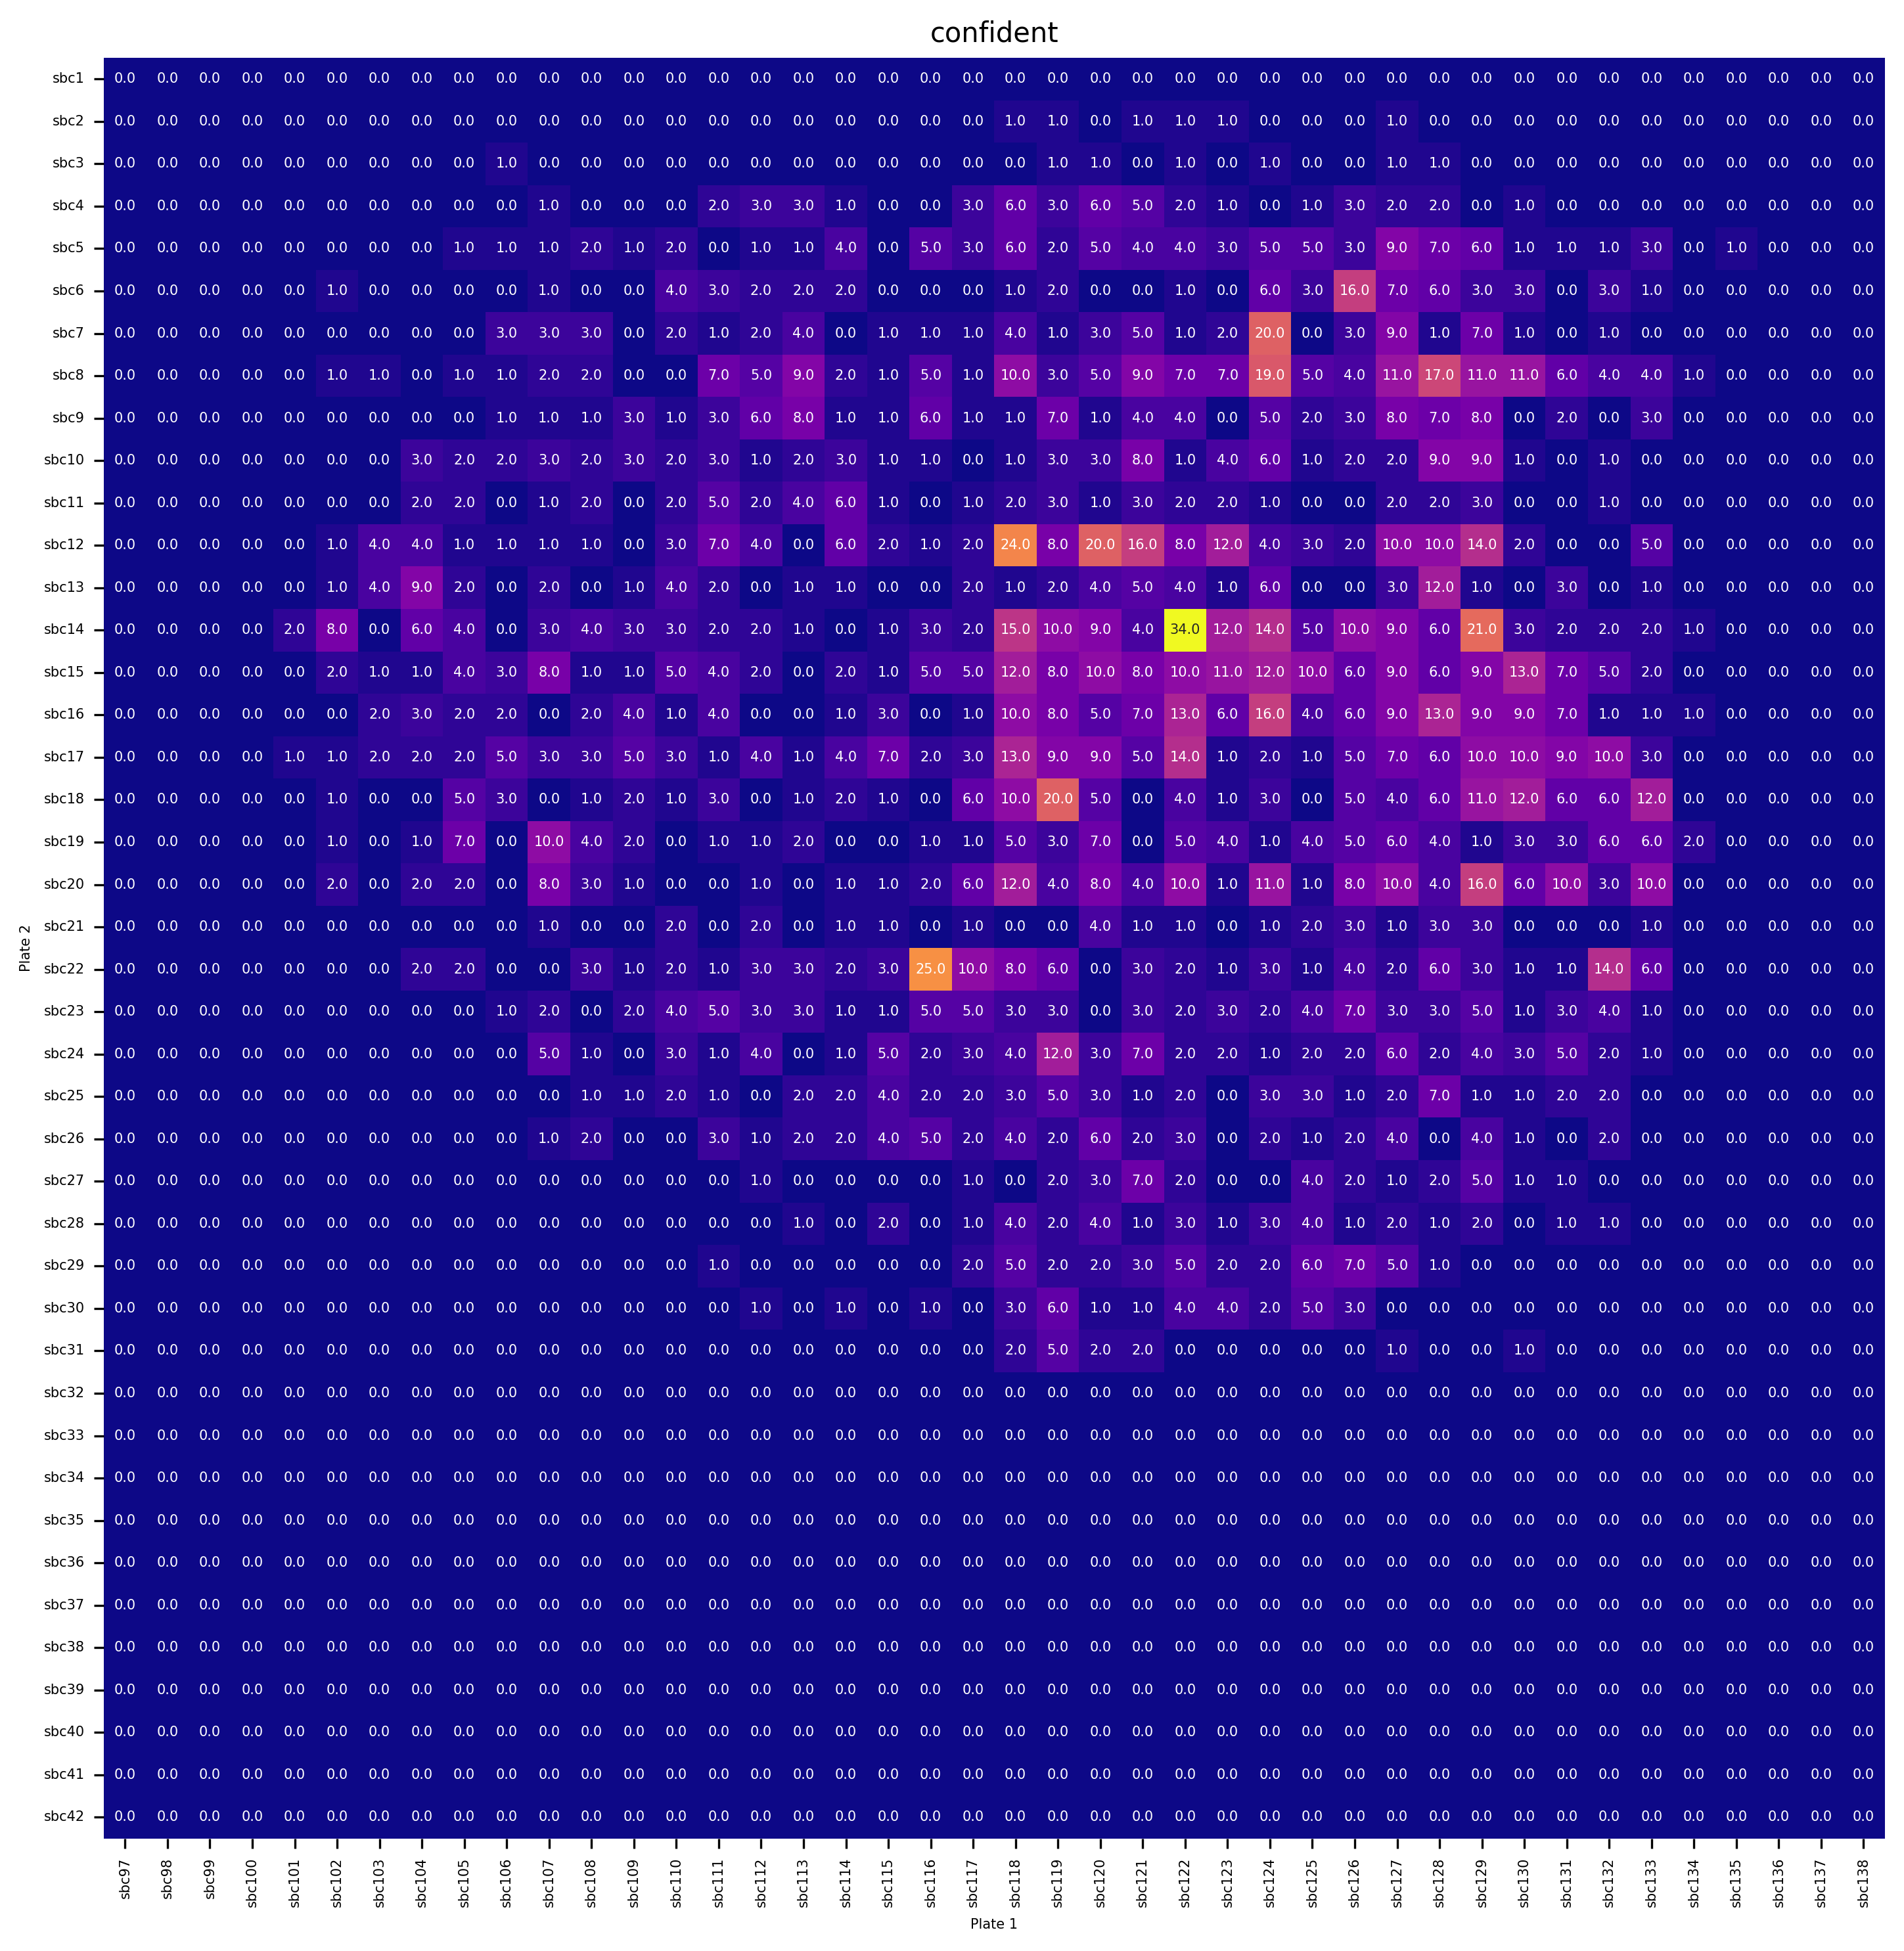

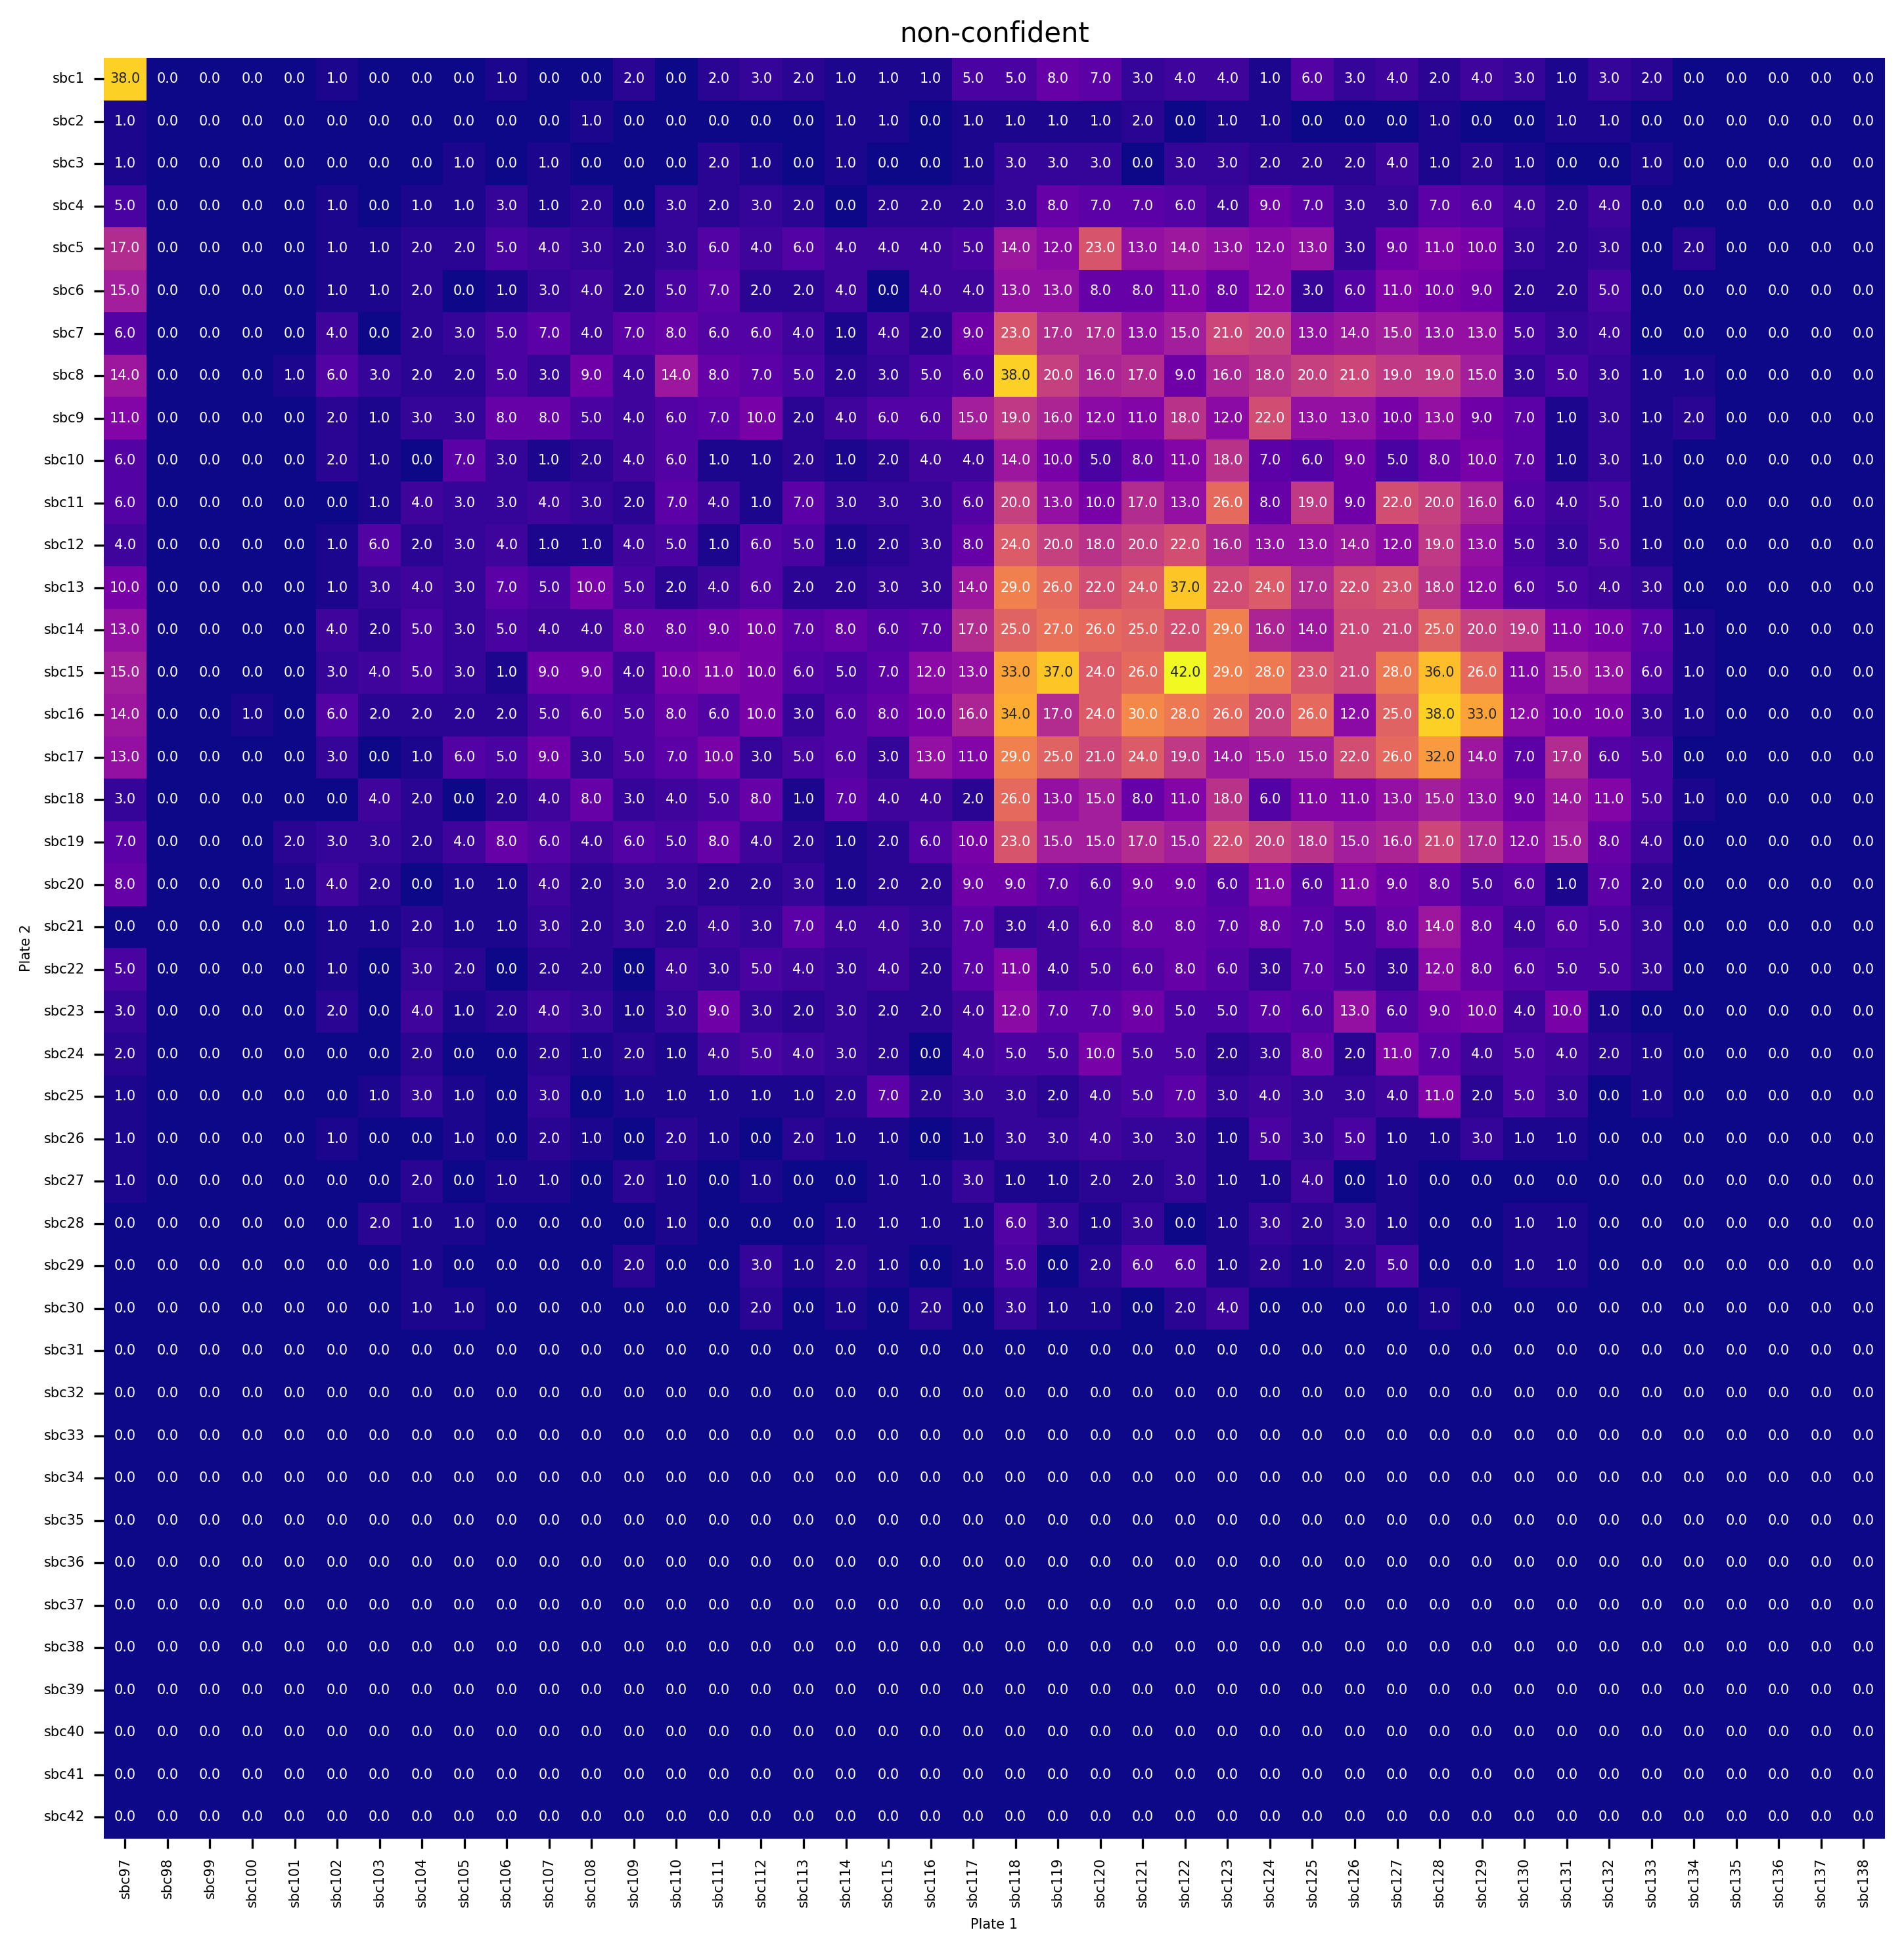

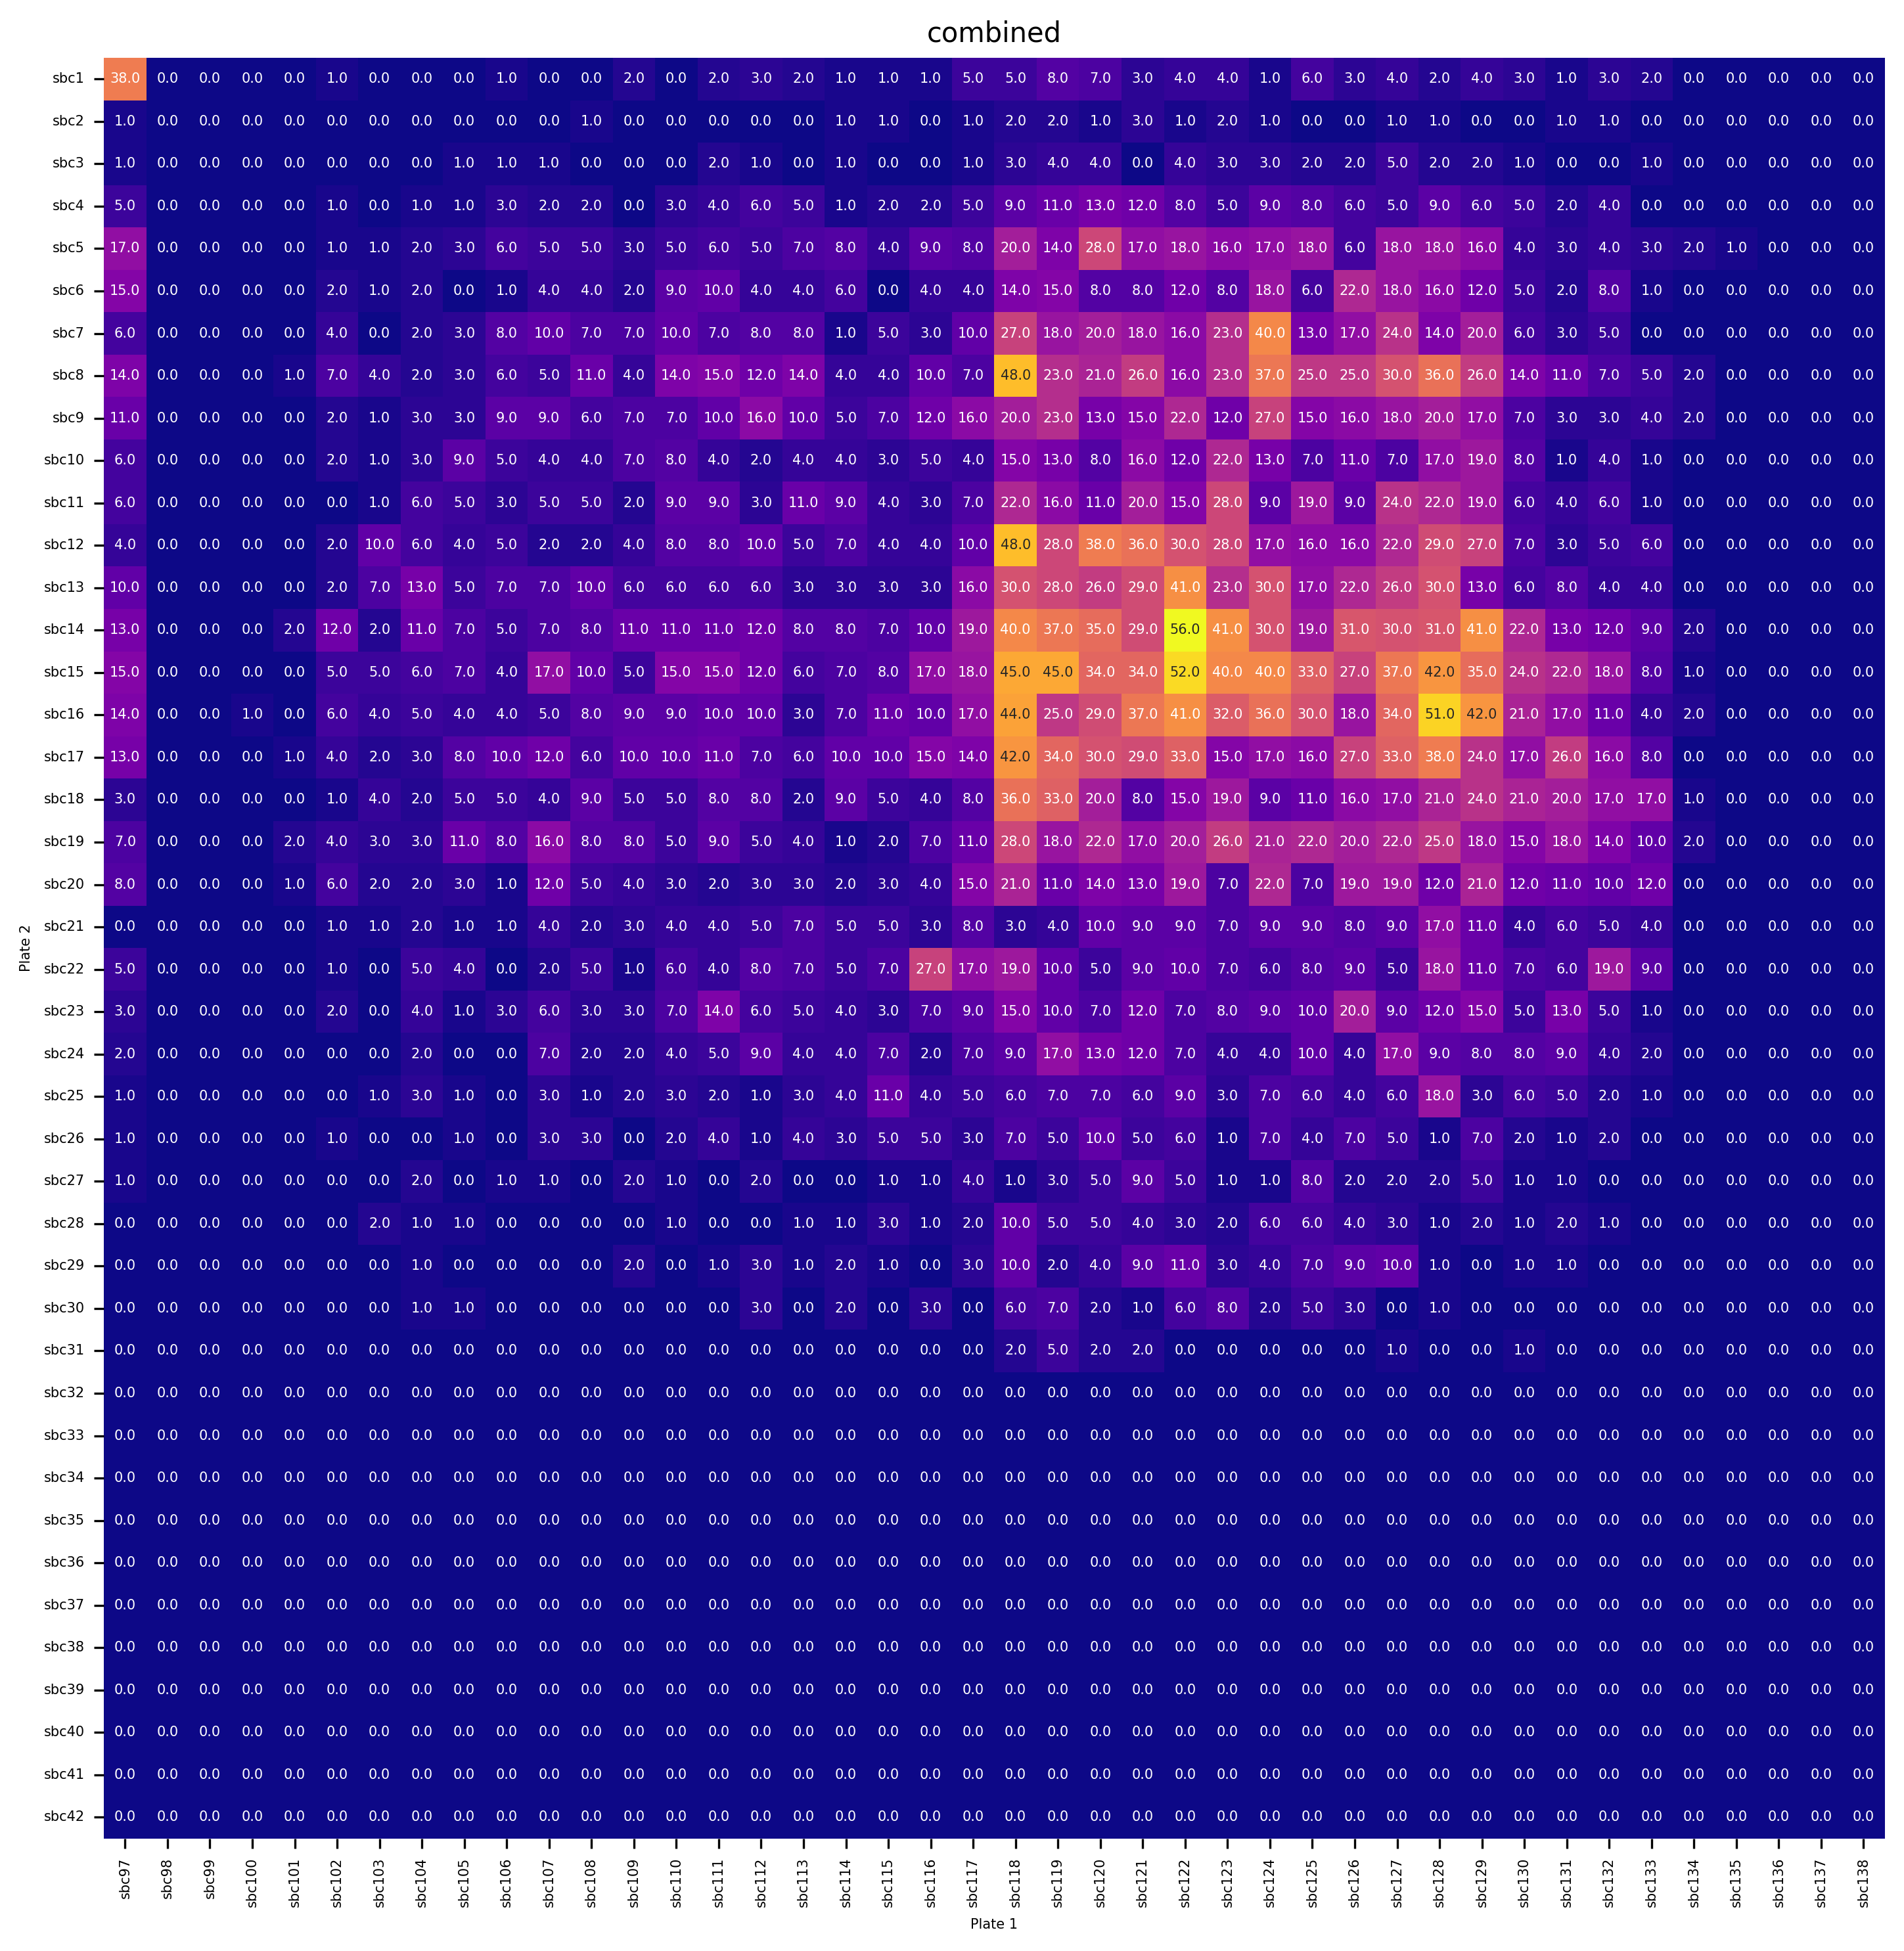

In [49]:

for lab, sub in [
    ("confident", xy_nn[xy_nn["label"] == "confident"]),
    ("non-confident", xy_nn[xy_nn["label"] == "non-confident"]),
    ("combined", xy_nn),
]:
    plt.figure(figsize=(10, 10), dpi=300)
    heatmap_data = pivot_xy_counts(sub)
    sns.heatmap(
        heatmap_data.T,
        annot=True,
        fmt=".1f",
        cmap="plasma",
        square=True,
        cbar=False,
        annot_kws={"size": 5},
        xticklabels=1,
        yticklabels=1,
    )
    plt.xticks(fontsize=5)
    plt.yticks(fontsize=5)
    plt.xlabel("Plate 1", fontsize=5)
    plt.ylabel("Plate 2", fontsize=5)
    plt.title(lab, fontsize=10)
    plt.tight_layout()
    fname = "heatmap_" + lab.replace("-", "_") + ".png"
    plt.savefig(fname, dpi=300)
    plt.show()

KeyError: 'Could not find key celltype in .var_names or .obs.columns.'

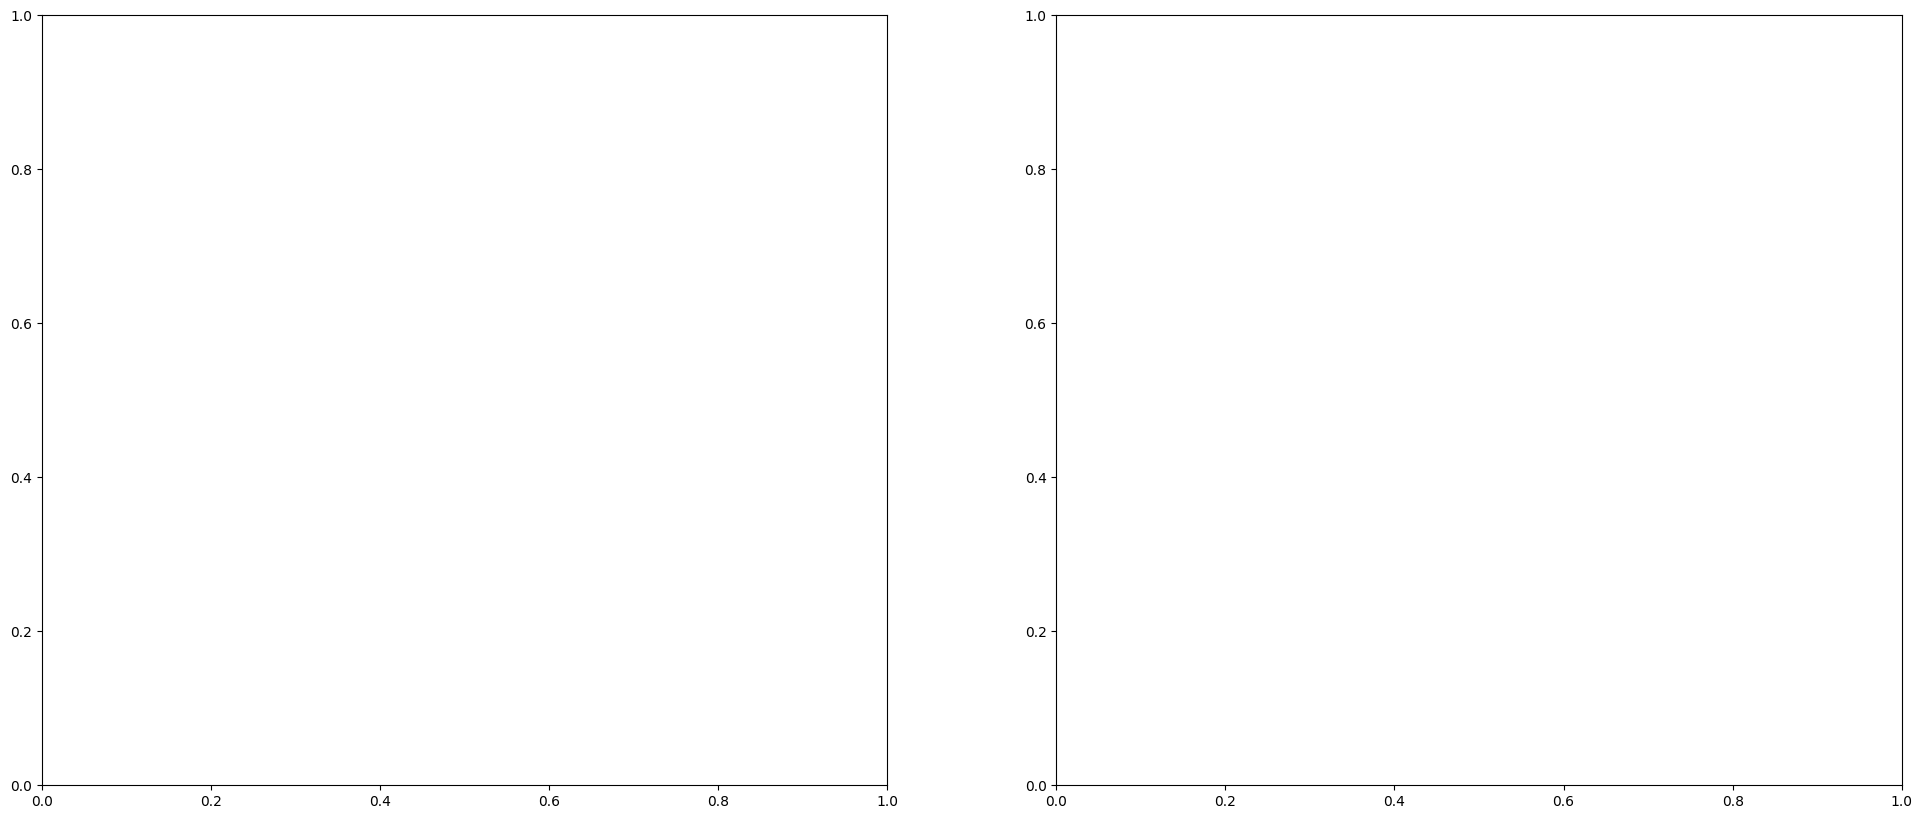

In [50]:
spatial_mask = adata.obs["spatial_x"].notna() & adata.obs["spatial_y"].notna()
adata_sp = adata[spatial_mask].copy()

rows = sorted(adata_sp.obs["spatial_x"].unique(), key=lambda s: int(''.join(filter(str.isdigit, s))))
cols = sorted(adata_sp.obs["spatial_y"].unique(), key=lambda s: int(''.join(filter(str.isdigit, s))))
if not ascend:
    rows = rows[::-1]
    cols = cols[::-1]

row_map = {bc: i + 1 for i, bc in enumerate(rows)}
col_map = {bc: i + 1 for i, bc in enumerate(cols)}
coords_x = adata_sp.obs["spatial_x"].map(row_map).values.astype(float)
coords_y = adata_sp.obs["spatial_y"].map(col_map).values.astype(float)

jitter_radius = 0.3
pair_keys = list(zip(coords_x, coords_y))
from collections import defaultdict
group_indices = defaultdict(list)
for i, key in enumerate(pair_keys):
    group_indices[key].append(i)
for key, indices in group_indices.items():
    n = len(indices)
    if n <= 1:
        continue
    for rank, i in enumerate(indices):
        angle = 2 * np.pi * rank / n
        coords_x[i] += jitter_radius * np.cos(angle)
        coords_y[i] += jitter_radius * np.sin(angle)

adata_sp.obsm["X_spatial"] = np.column_stack([coords_x, coords_y])

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sc.pl.embedding(adata_sp, basis="spatial", color="celltype", ax=axes[0], show=False, title="Spatial (celltype)")
sc.pl.umap(adata_sp, color="celltype", ax=axes[1], show=False, title="UMAP (celltype)")

plt.tight_layout()
plt.show()

In [ ]:
adata.write('E11_spatial.h5ad')